## Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
from collections import Counter

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Settings
plt.style.use('ggplot')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\karbi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\karbi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\karbi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\karbi\AppData\Roaming\nltk_data...


✅ All libraries imported successfully!


## Load Data

In [3]:
# Load datasets
fake_df = pd.read_csv(r'../data/datasets/fake-and-real-news-dataset/Fake.csv')
true_df = pd.read_csv(r'../data/datasets/fake-and-real-news-dataset/True.csv')

# Add labels
fake_df['label'] = 0  # 0 = Fake
true_df['label'] = 1  # 1 = True

# Combine datasets
df = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)

print(f"Total articles: {len(df)}")
print(f"Fake: {len(fake_df)} | True: {len(true_df)}")
print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Total articles: 44898
Fake: 23481 | True: 21417

Dataset shape: (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he...",News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under th...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered ...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES),"On Christmas day, Donald Trump announced that he would be back to work the following day, but ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech,Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentionin...,News,"December 25, 2017",0


## Data Overview

In [4]:
# Basic info
print("="*60)
print("DATASET INFO")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)
print(df['label'].value_counts())
print(f"\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

print("\n" + "="*60)
print("SUBJECT DISTRIBUTION")
print("="*60)
print(df['subject'].value_counts())

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None

MISSING VALUES
title      0
text       0
subject    0
date       0
label      0
dtype: int64

CLASS DISTRIBUTION
label
0    23481
1    21417
Name: count, dtype: int64

Percentage:
label
0    52.298543
1    47.701457
Name: proportion, dtype: float64

SUBJECT DISTRIBUTION
subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


## Visualize Class Distribution

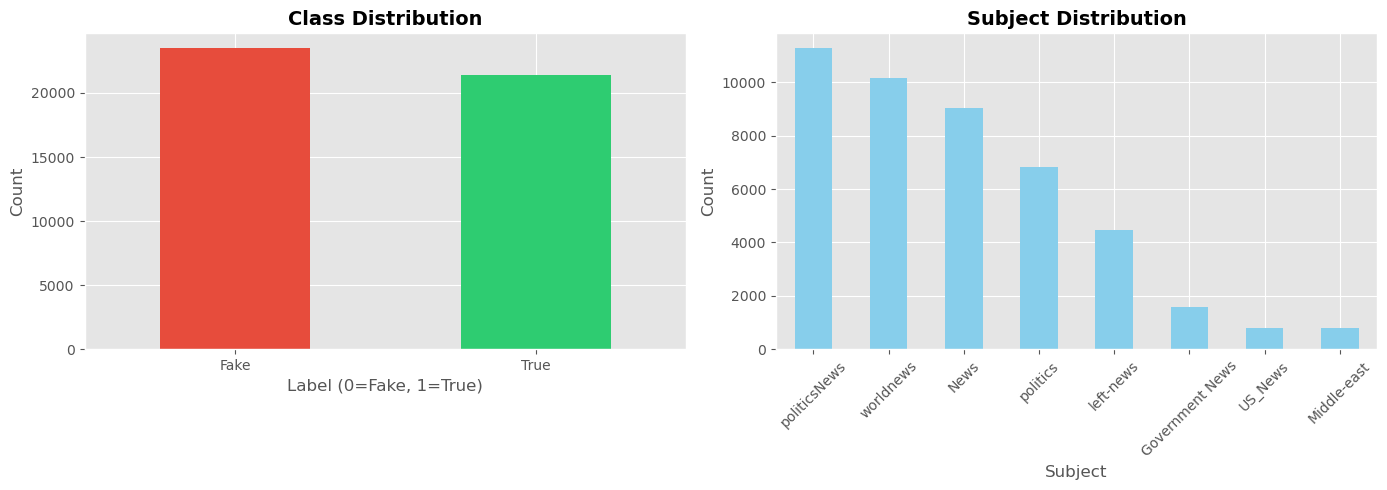

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label (0=Fake, 1=True)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Fake', 'True'], rotation=0)

# Subject distribution
df['subject'].value_counts().plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Subject Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Text Length Analysis

In [6]:
# Calculate text lengths
df['title_length'] = df['title'].astype(str).apply(len)
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print("="*60)
print("TEXT LENGTH STATISTICS")
print("="*60)
print("\nTitle Length:")
print(df.groupby('label')['title_length'].describe())

print("\nText Length:")
print(df.groupby('label')['text_length'].describe())

print("\nWord Count:")
print(df.groupby('label')['word_count'].describe())

TEXT LENGTH STATISTICS

Title Length:
         count       mean        std   min   25%   50%    75%    max
label                                                               
0      23481.0  94.198032  27.184433   8.0  77.0  90.0  105.0  286.0
1      21417.0  64.667881   9.168999  26.0  59.0  64.0   70.0  133.0

Text Length:
         count         mean          std  min     25%     50%     75%      max
label                                                                         
0      23481.0  2547.396235  2532.884399  1.0  1433.0  2166.0  3032.0  51794.0
1      21417.0  2383.278517  1684.835730  1.0   914.0  2222.0  3237.0  29781.0

Word Count:
         count        mean         std  min    25%    50%    75%     max
label                                                                   
0      23481.0  423.197905  408.388890  0.0  240.0  363.0  506.0  8135.0
1      21417.0  385.640099  274.006204  0.0  148.0  359.0  525.0  5172.0


## Visualize Text Length Distribution

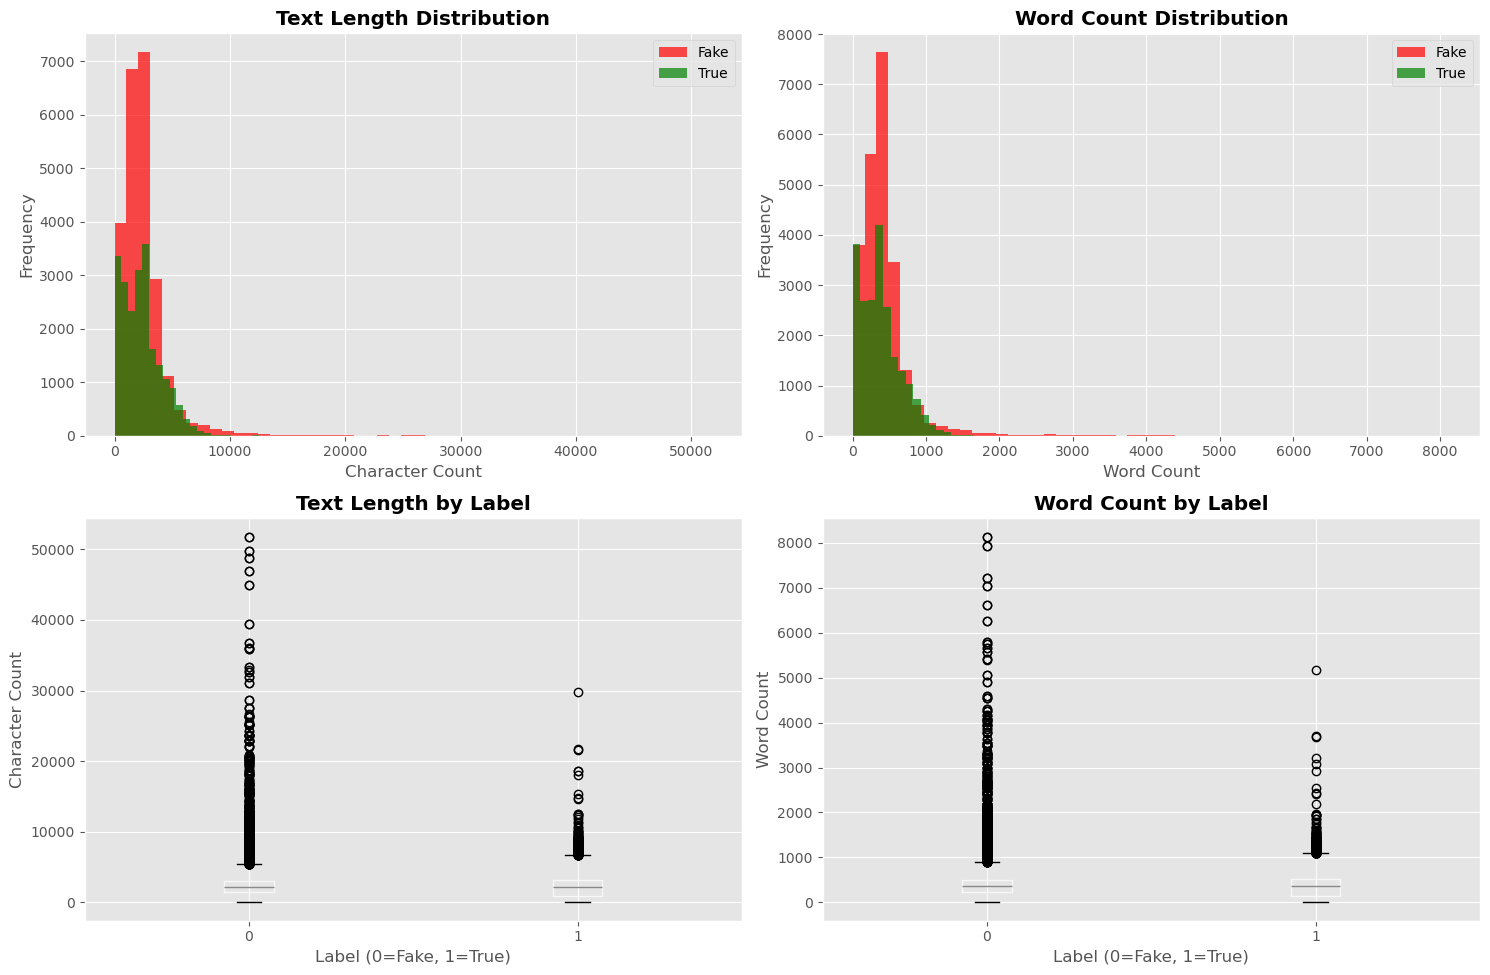

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Text length distribution
axes[0, 0].hist(df[df['label']==0]['text_length'], bins=50, alpha=0.7, label='Fake', color='red')
axes[0, 0].hist(df[df['label']==1]['text_length'], bins=50, alpha=0.7, label='True', color='green')
axes[0, 0].set_title('Text Length Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Character Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Word count distribution
axes[0, 1].hist(df[df['label']==0]['word_count'], bins=50, alpha=0.7, label='Fake', color='red')
axes[0, 1].hist(df[df['label']==1]['word_count'], bins=50, alpha=0.7, label='True', color='green')
axes[0, 1].set_title('Word Count Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Box plot - text length
df.boxplot(column='text_length', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Text Length by Label', fontweight='bold')
axes[1, 0].set_xlabel('Label (0=Fake, 1=True)')
axes[1, 0].set_ylabel('Character Count')
plt.suptitle('')

# Box plot - word count
df.boxplot(column='word_count', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Label', fontweight='bold')
axes[1, 1].set_xlabel('Label (0=Fake, 1=True)')
axes[1, 1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.show()

## Check for Very Short/ Very Long Articles

In [8]:
# Find articles that are too short or too long
print("="*60)
print("OUTLIER ANALYSIS")
print("="*60)

# Very short articles (less than 100 characters)
short_articles = df[df['text_length'] < 100]
print(f"\nArticles with less than 100 characters: {len(short_articles)}")
print(f"Percentage: {len(short_articles)/len(df)*100:.2f}%")

# Very long articles (more than 10000 characters)
long_articles = df[df['text_length'] > 10000]
print(f"\nArticles with more than 10000 characters: {len(long_articles)}")
print(f"Percentage: {len(long_articles)/len(df)*100:.2f}%")

# Sample a very short article
if len(short_articles) > 0:
    print("\n" + "="*60)
    print("SAMPLE SHORT ARTICLE")
    print("="*60)
    sample = short_articles.iloc[0]
    print(f"Title: {sample['title']}")
    print(f"Text: {sample['text']}")
    print(f"Length: {sample['text_length']} characters")

OUTLIER ANALYSIS

Articles with less than 100 characters: 1040
Percentage: 2.32%

Articles with more than 10000 characters: 352
Percentage: 0.78%

SAMPLE SHORT ARTICLE
Title: TAKE OUR POLL: Who Do You Think President Trump Should Pick To Replace James Comey?
Text:  
Length: 1 characters


## Text Preprocessing Function

In [9]:
def preprocess_text(text):
    """
    Comprehensive text preprocessing pipeline
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions and hashtags
    text = re.sub(r'\@\w+|\#\w+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join back to string
    cleaned_text = ' '.join(tokens)
    
    return cleaned_text

# Test the function
sample_text = df.iloc[0]['text']
print("Original text (first 300 chars):")
print(sample_text[:300])
print("\n" + "="*60)
print("\nCleaned text (first 300 chars):")
cleaned = preprocess_text(sample_text)
print(cleaned[:300])

Original text (first 300 chars):
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger a


Cleaned text (first 300 chars):
donald trump wish american happy new year leave instead give shout enemy hater dishonest fake news medium former reality show star one job country rapidly grows stronger smarter want wish friend supporter enemy hater even dishonest fake news medium happy healthy new year president angry pant tweeted


## Apply Preprocessing to Dataset

In [10]:
# This will take a few minutes!
print("Starting text preprocessing...")
print("This may take 5-10 minutes for 44k articles...")

# Preprocess text column
df['cleaned_text'] = df['text'].apply(lambda x: preprocess_text(str(x)))

# Preprocess title column
df['cleaned_title'] = df['title'].apply(lambda x: preprocess_text(str(x)))

print("✅ Preprocessing complete!")

# Check results
print("\n" + "="*60)
print("SAMPLE CLEANED TEXT")
print("="*60)
print(f"Original: {df.iloc[0]['text'][:200]}")
print(f"\nCleaned: {df.iloc[0]['cleaned_text'][:200]}")

Starting text preprocessing...
This may take 5-10 minutes for 44k articles...
✅ Preprocessing complete!

SAMPLE CLEANED TEXT
Original: Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former rea

Cleaned: donald trump wish american happy new year leave instead give shout enemy hater dishonest fake news medium former reality show star one job country rapidly grows stronger smarter want wish friend suppo


## Remove Empty / Too Short Cleaned Texts

In [11]:
# Check for empty or very short cleaned texts
df['cleaned_text_length'] = df['cleaned_text'].apply(len)

print("Before filtering:")
print(f"Total articles: {len(df)}")

# Filter out articles with less than 50 characters after cleaning
df_filtered = df[df['cleaned_text_length'] >= 50].copy()

print(f"\nAfter filtering (removed articles < 50 chars):")
print(f"Total articles: {len(df_filtered)}")
print(f"Removed: {len(df) - len(df_filtered)} articles")

# Update df
df = df_filtered.reset_index(drop=True)

print(f"\n✅ Final dataset size: {len(df)} articles")
print(f"Fake: {len(df[df['label']==0])} | True: {len(df[df['label']==1])}")

Before filtering:
Total articles: 44898

After filtering (removed articles < 50 chars):
Total articles: 43944
Removed: 954 articles

✅ Final dataset size: 43944 articles
Fake: 22528 | True: 21416


## Word Cloud Visualization

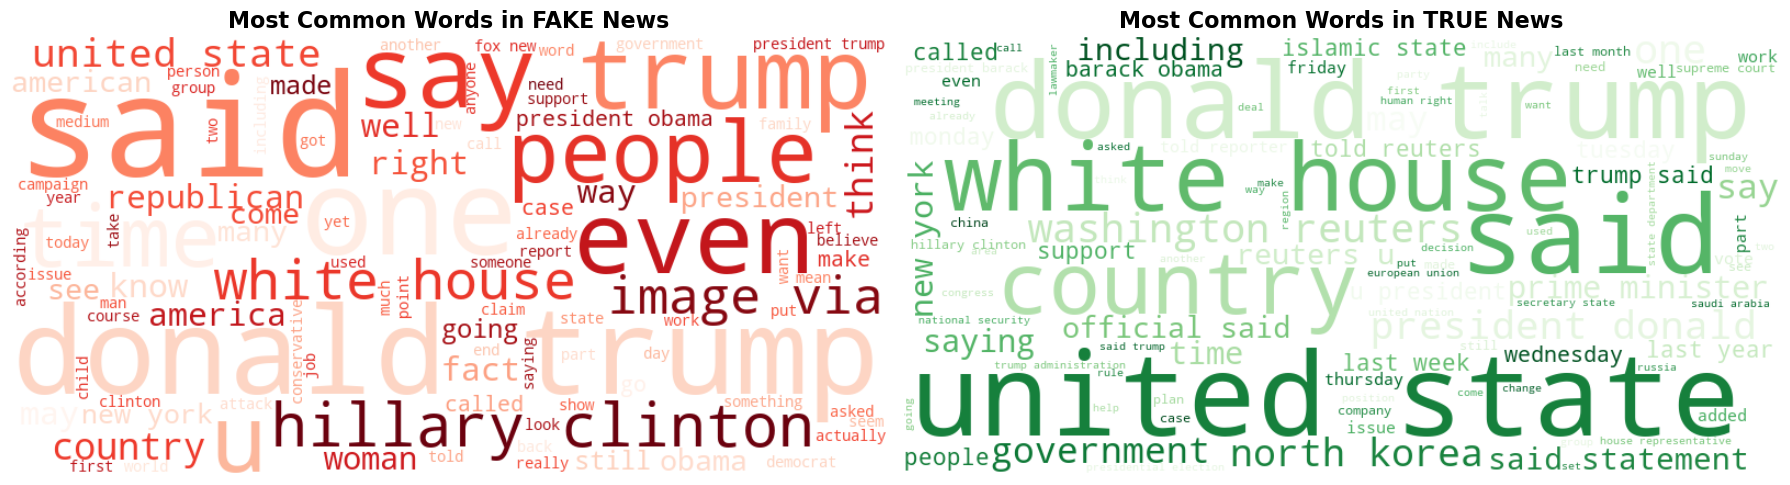

In [12]:
# Create word clouds for fake and true news
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Fake news word cloud
fake_text = ' '.join(df[df['label']==0]['cleaned_text'].values)
wordcloud_fake = WordCloud(width=800, height=400, 
                           background_color='white',
                           colormap='Reds',
                           max_words=100).generate(fake_text)

axes[0].imshow(wordcloud_fake, interpolation='bilinear')
axes[0].set_title('Most Common Words in FAKE News', fontsize=16, fontweight='bold')
axes[0].axis('off')

# True news word cloud
true_text = ' '.join(df[df['label']==1]['cleaned_text'].values)
wordcloud_true = WordCloud(width=800, height=400,
                           background_color='white',
                           colormap='Greens',
                           max_words=100).generate(true_text)

axes[1].imshow(wordcloud_true, interpolation='bilinear')
axes[1].set_title('Most Common Words in TRUE News', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Most Common Words Analysis

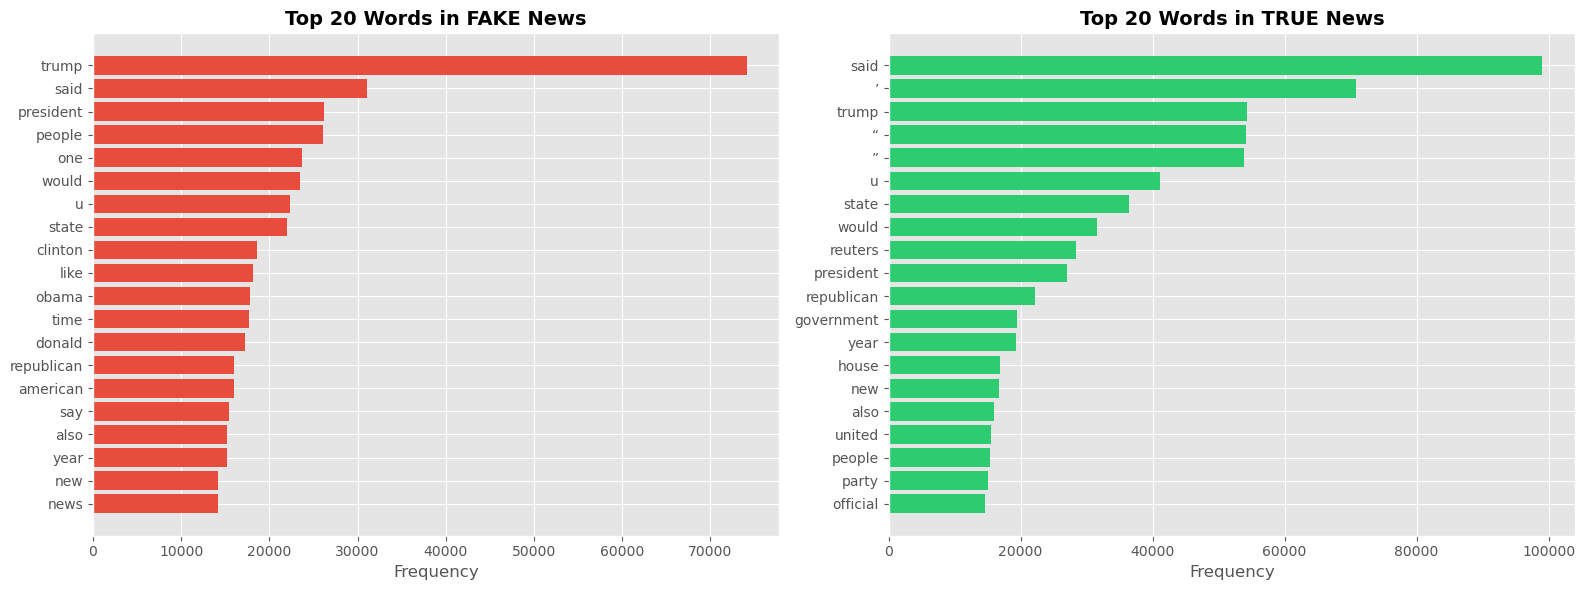

TOP 20 WORDS COMPARISON

FAKE NEWS:
trump: 74105
said: 31015
president: 26180
people: 26048
one: 23751
would: 23424
u: 22327
state: 22002
clinton: 18640
like: 18159
obama: 17797
time: 17713
donald: 17219
republican: 16036
american: 16033
say: 15440
also: 15241
year: 15198
new: 14158
news: 14138

TRUE NEWS:
said: 99042
’: 70768
trump: 54347
“: 54140
”: 53861
u: 41177
state: 36395
would: 31525
reuters: 28403
president: 26997
republican: 22109
government: 19466
year: 19280
house: 16935
new: 16786
also: 15953
united: 15574
people: 15324
party: 14990
official: 14580


In [13]:
def get_top_words(text_series, n=20):
    """Get top N most common words"""
    all_words = ' '.join(text_series.values).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for fake and true news
fake_top_words = get_top_words(df[df['label']==0]['cleaned_text'], n=20)
true_top_words = get_top_words(df[df['label']==1]['cleaned_text'], n=20)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fake news top words
fake_words, fake_counts = zip(*fake_top_words)
axes[0].barh(fake_words, fake_counts, color='#e74c3c')
axes[0].set_title('Top 20 Words in FAKE News', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# True news top words
true_words, true_counts = zip(*true_top_words)
axes[1].barh(true_words, true_counts, color='#2ecc71')
axes[1].set_title('Top 20 Words in TRUE News', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("="*60)
print("TOP 20 WORDS COMPARISON")
print("="*60)
print("\nFAKE NEWS:")
for word, count in fake_top_words:
    print(f"{word}: {count}")
    
print("\nTRUE NEWS:")
for word, count in true_top_words:
    print(f"{word}: {count}")

## Save Processed Data

In [ ]:
# Save the cleaned dataset
output_path = '../data/processed/cleaned_news_data.csv'

# Create directory if it doesn't exist
import os
os.makedirs('../data/processed', exist_ok=True)

# Select relevant columns
df_final = df[['title', 'text', 'cleaned_title', 'cleaned_text', 'subject', 'date', 'label']].copy()

# Save
df_final.to_csv(output_path, index=False)

print(f"✅ Cleaned dataset saved to: {output_path}")
print(f"Final dataset shape: {df_final.shape}")
print(f"\nColumns saved: {df_final.columns.tolist()}")

✅ Cleaned dataset saved to: ../data/processed/cleaned_news_data.csv
Final dataset shape: (43944, 7)

Columns saved: ['title', 'text', 'cleaned_title', 'cleaned_text', 'subject', 'date', 'label']


## Summary Statistics

In [15]:
print("="*60)
print("FINAL DATASET SUMMARY")
print("="*60)
print(f"Total articles: {len(df_final)}")
print(f"Fake news: {len(df_final[df_final['label']==0])} ({len(df_final[df_final['label']==0])/len(df_final)*100:.1f}%)")
print(f"True news: {len(df_final[df_final['label']==1])} ({len(df_final[df_final['label']==1])/len(df_final)*100:.1f}%)")

print(f"\nAverage cleaned text length:")
print(f"  Fake: {df_final[df_final['label']==0]['cleaned_text'].apply(len).mean():.0f} characters")
print(f"  True: {df_final[df_final['label']==1]['cleaned_text'].apply(len).mean():.0f} characters")

print(f"\nAverage word count (cleaned):")
print(f"  Fake: {df_final[df_final['label']==0]['cleaned_text'].apply(lambda x: len(x.split())).mean():.0f} words")
print(f"  True: {df_final[df_final['label']==1]['cleaned_text'].apply(lambda x: len(x.split())).mean():.0f} words")

print("\n✅ EDA & Preprocessing Complete!")
print("🎯 Ready for model training!")

FINAL DATASET SUMMARY
Total articles: 43944
Fake news: 22528 (51.3%)
True news: 21416 (48.7%)

Average cleaned text length:
  Fake: 1763 characters
  True: 1698 characters

Average word count (cleaned):
  Fake: 239 words
  True: 234 words

✅ EDA & Preprocessing Complete!
🎯 Ready for model training!
